# Classificador de níveis de líquido em uma caneca

Feito por Pither Mikael Gonçalves Duarte

Este notebook utiliza imagens sintéticas geradas no Blender para classificar a caneca em quatro estados:

- empty
- mostly_empty
- half_full
- full

O modelo utiliza transfer learning com MobileNetV2.

In [13]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub

from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

In [15]:
DATASET_DIR = Path(
    "/content/drive/MyDrive/Fastcamp/Card_09/dataset_caneca"
)

RESULTS_DIR = Path(
    "/content/drive/MyDrive/Fastcamp/Card_09/resultados_caneca_pratica"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

print("Dataset:", DATASET_DIR)
print("Resultados:", RESULTS_DIR)

Dataset: /content/drive/MyDrive/Fastcamp/Card_09/dataset_caneca
Resultados: /content/drive/MyDrive/Fastcamp/Card_09/resultados_caneca_pratica


In [16]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 8

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 320 files belonging to 4 classes.
Found 80 files belonging to 4 classes.
Found 40 files belonging to 4 classes.


In [18]:
class_names = ["A", "B", "C"]

In [19]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Quantidade de classes:", NUM_CLASSES)

Classes: ['empty', 'full', 'half_full', 'mostly_empty']
Quantidade de classes: 4


In [20]:
for division in ["train", "val", "test"]:
    division_dir = DATASET_DIR / division

    print(f"\n{division.upper()}")

    total = 0

    for class_name in class_names:
        class_dir = division_dir / class_name
        quantity = len(list(class_dir.glob("*.png")))
        total += quantity

        print(f"{class_name}: {quantity}")

    print(f"Total: {total}")


TRAIN
empty: 80
full: 80
half_full: 80
mostly_empty: 80
Total: 320

VAL
empty: 20
full: 20
half_full: 20
mostly_empty: 20
Total: 80

TEST
empty: 10
full: 10
half_full: 10
mostly_empty: 10
Total: 40


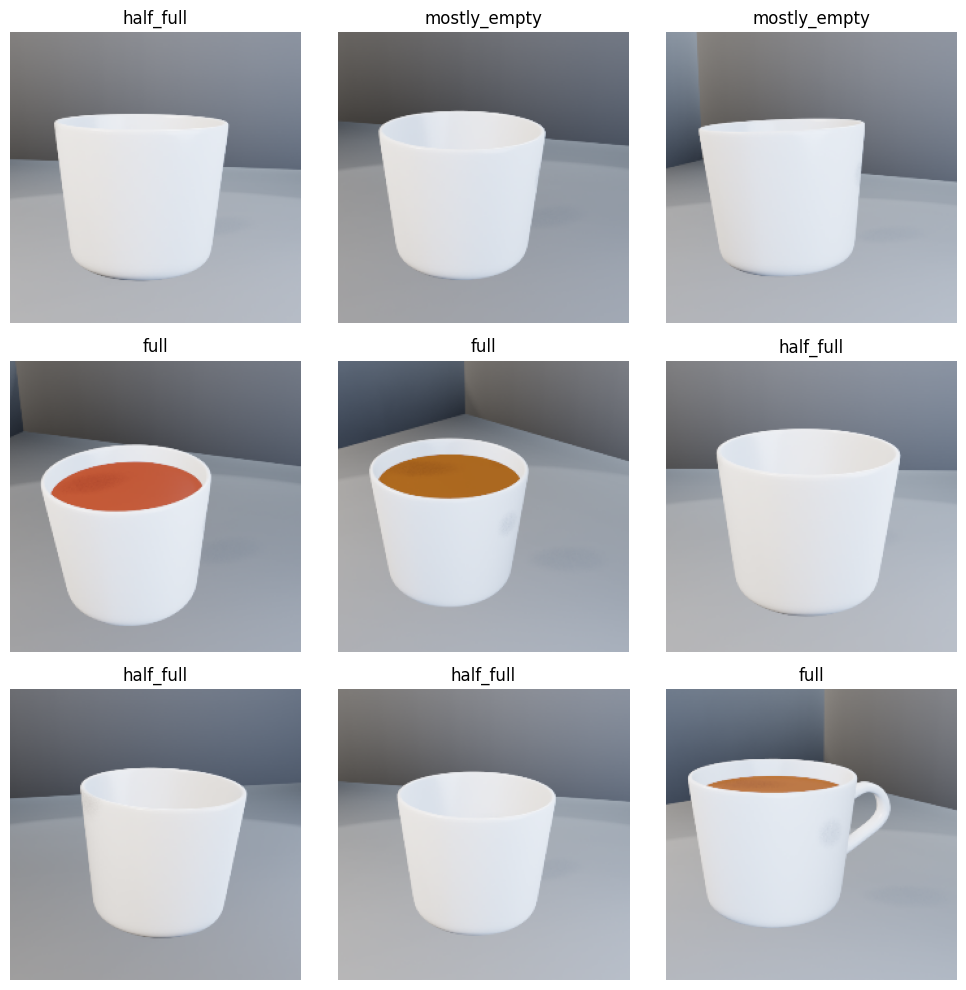

In [21]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for index in range(9):
        ax = plt.subplot(3, 3, index + 1)

        plt.imshow(images[index].numpy().astype("uint8"))
        plt.title(class_names[int(labels[index])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_ds = test_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [23]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

base_model.trainable = False

model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(
        scale=1.0 / 127.5,
        offset=-1
    ),
    base_model,
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.2625 - loss: 1.4523 - val_accuracy: 0.4125 - val_loss: 1.2126
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4812 - loss: 1.1494 - val_accuracy: 0.4375 - val_loss: 1.0491
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4938 - loss: 1.0317 - val_accuracy: 0.4625 - val_loss: 0.9826
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4844 - loss: 1.0268 - val_accuracy: 0.4625 - val_loss: 0.9598
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5063 - loss: 0.9387 - val_accuracy: 0.5500 - val_loss: 0.9404
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5156 - loss: 0.9375 - val_accuracy: 0.4375 - val_loss: 0.9352
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5156 - loss: 0.9274 - val_accuracy: 0.5000 - val_loss: 0.9161
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5125 - loss: 0.9289 - val_accuracy: 0.4750 - val_loss: 0.9081

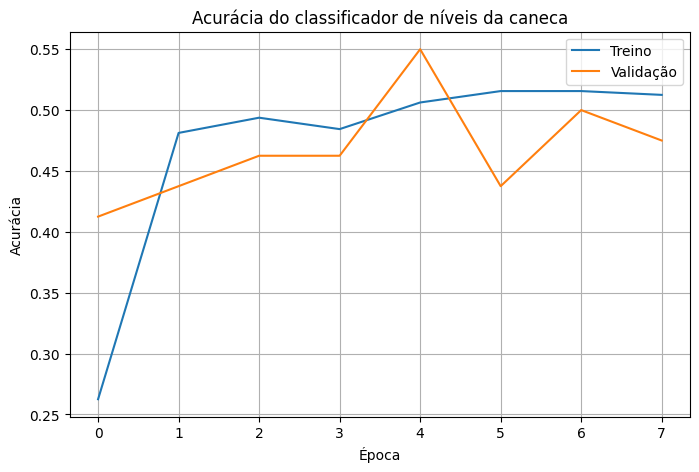

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Treino"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validação"
)

plt.title("Acurácia do classificador de níveis da caneca")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)

plt.savefig(
    RESULTS_DIR / "acuracia_caneca.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

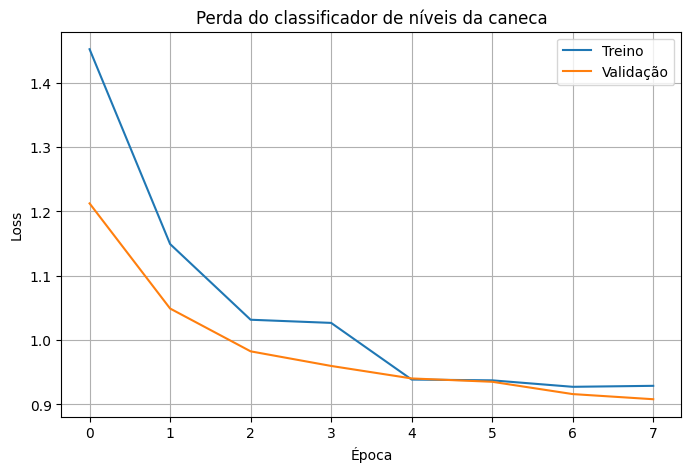

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Treino"
)

plt.plot(
    history.history["val_loss"],
    label="Validação"
)

plt.title("Perda do classificador de níveis da caneca")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    RESULTS_DIR / "perda_caneca.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [28]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Loss no teste: {test_loss:.4f}")
print(f"Acurácia no teste: {test_accuracy * 100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6500 - loss: 0.8340
Loss no teste: 0.8340
Acurácia no teste: 65.00%


In [29]:
true_labels = []
predicted_labels = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predictions = tf.argmax(predictions, axis=1)

    true_labels.extend(labels.numpy())
    predicted_labels.extend(predictions.numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

In [30]:
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       empty     0.6250    0.5000    0.5556        10
        full     1.0000    1.0000    1.0000        10
   half_full     0.6667    0.2000    0.3077        10
mostly_empty     0.4737    0.9000    0.6207        10

    accuracy                         0.6500        40
   macro avg     0.6913    0.6500    0.6210        40
weighted avg     0.6913    0.6500    0.6210        40



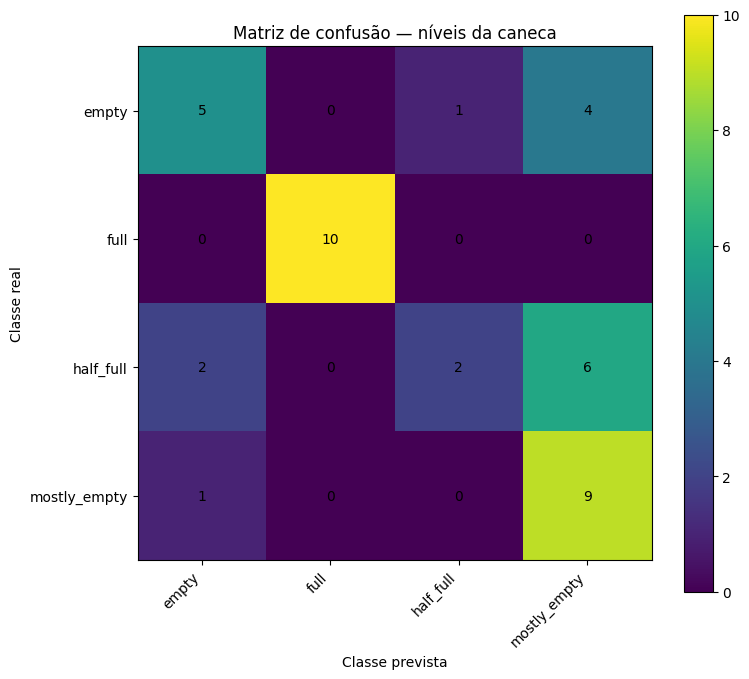

In [31]:
matrix = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 7))
plt.imshow(matrix)
plt.title("Matriz de confusão — níveis da caneca")
plt.colorbar()

positions = np.arange(len(class_names))

plt.xticks(
    positions,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    positions,
    class_names
)

plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        plt.text(
            column,
            row,
            matrix[row, column],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "matriz_confusao_caneca.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

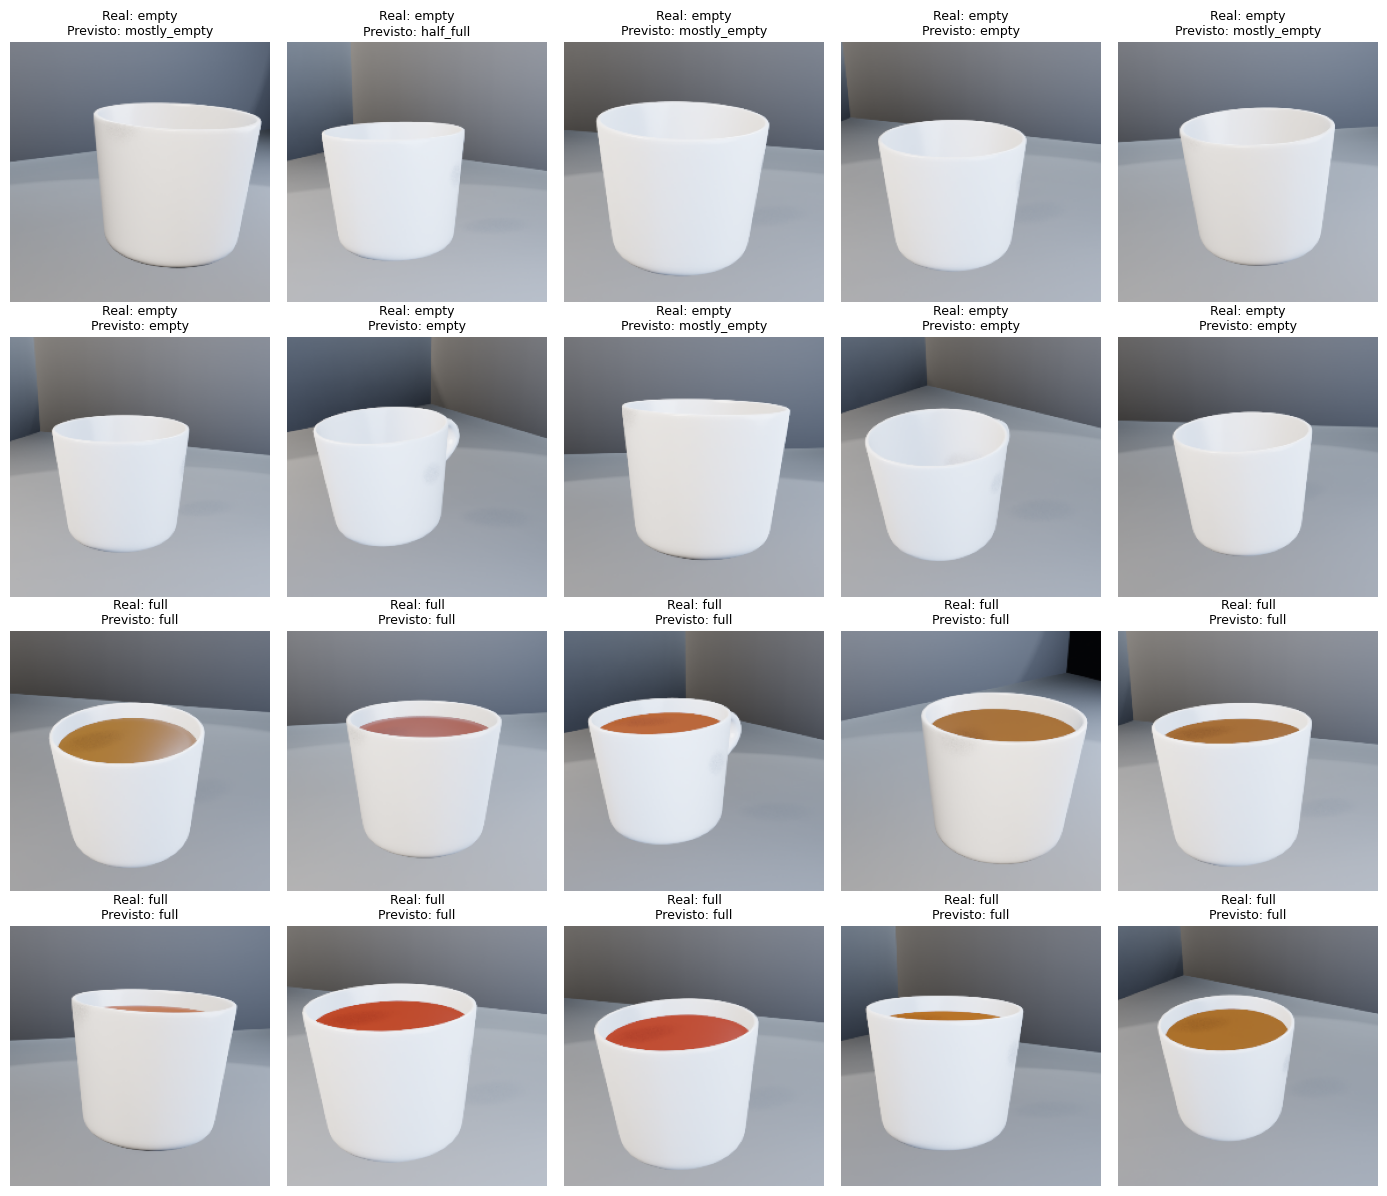

In [32]:
plt.figure(figsize=(14, 12))

image_counter = 0

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predictions = tf.argmax(predictions, axis=1)

    for index in range(len(images)):
        if image_counter >= 20:
            break

        ax = plt.subplot(4, 5, image_counter + 1)

        plt.imshow(
            images[index].numpy().astype("uint8")
        )

        real_class = class_names[int(labels[index])]
        predicted_class = class_names[int(predictions[index])]

        plt.title(
            f"Real: {real_class}\n"
            f"Previsto: {predicted_class}",
            fontsize=9
        )

        plt.axis("off")
        image_counter += 1

    if image_counter >= 20:
        break

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "previsoes_caneca.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

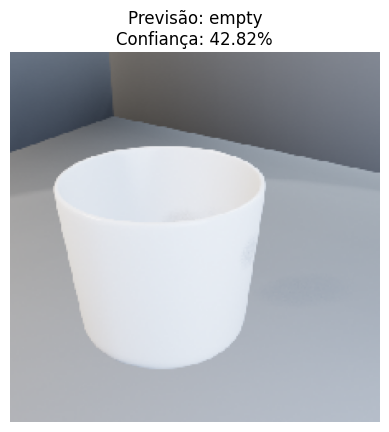

In [33]:
IMAGE_PATH = next(
    (TEST_DIR / "half_full").glob("*.png")
)

image = tf.keras.utils.load_img(
    IMAGE_PATH,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_array, axis=0)

prediction = model.predict(
    image_batch,
    verbose=0
)

probabilities = tf.nn.softmax(
    prediction[0]
)

predicted_index = int(
    tf.argmax(probabilities)
)

predicted_class = class_names[predicted_index]
confidence = float(probabilities[predicted_index])

plt.imshow(image)
plt.title(
    f"Previsão: {predicted_class}\n"
    f"Confiança: {confidence * 100:.2f}%"
)
plt.axis("off")
plt.show()

In [34]:
MODEL_PATH = (
    RESULTS_DIR /
    "classificador_caneca_pratica.keras"
)

model.save(MODEL_PATH)

print("Modelo salvo em:")
print(MODEL_PATH)

Modelo salvo em:
/content/drive/MyDrive/Fastcamp/Card_09/resultados_caneca_pratica/classificador_caneca_pratica.keras


In [35]:
metadata = {
    "projeto": "Classificação de níveis de líquido em caneca",
    "tipo": "Prática própria",
    "dataset": str(DATASET_DIR),
    "classes": class_names,
    "quantidade_classes": NUM_CLASSES,
    "tamanho_imagem": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "epocas": EPOCHS,
    "acuracia_teste": float(test_accuracy),
    "loss_teste": float(test_loss)
}

with open(
    RESULTS_DIR / "metadata_caneca.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
        ensure_ascii=False
    )

print("Metadados salvos.")

Metadados salvos.
